# Notebook 02 — Preprocessing & Normalization

**Goal:** Normalize raw counts, select informative genes, reduce dimensionality, and correct for batch effects (patient-to-patient variability).

## Why normalize?

Raw UMI counts vary between cells due to capture efficiency — a cell with 10,000 total counts vs one with 2,000 counts will show apparent differences in gene expression that are purely technical.  
We normalize each cell to a fixed total (10,000 counts), then apply log1p to stabilize variance.

## Why Harmony batch correction?

Each patient is sequenced separately → technical differences between samples can dominate the signal.  
**Harmony** integrates multiple samples by iteratively correcting the PCA embedding without modifying the count matrix.

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')
from src.utils import (
    normalize_and_log,
    select_highly_variable_genes,
    run_pca,
    run_harmony_batch_correction,
    set_plot_style 
)

set_plot_style()
sc.settings.verbosity = 1

In [2]:
# Load output from notebook 01
adata = sc.read('../data/raw/adata_01_qc.h5ad')
print(f"Loaded: {adata.n_obs} cells × {adata.n_vars} genes")

Loaded: 5996 cells × 17897 genes


## 2.1 — Normalization + log1p

Standard scRNA-seq normalization pipeline:
1. **Normalize per cell** → each cell sums to 10,000 counts ("CPM-like")
2. **log1p** → log(x + 1) to handle zeros and compress dynamic range

In [3]:
adata = normalize_and_log(adata, target_sum=1e4)
print(f"Raw counts saved in adata.raw: {adata.raw is not None}")

Normalization done: target_sum=10000, log1p applied.
Raw counts saved in adata.raw: True


## 2.2 — Highly Variable Genes (HVGs)

From ~33,000 genes, we select the **3,000 most variable** across cells.  
These genes carry the most biological information for distinguishing cell types.  
Housekeeping genes (constant expression) are excluded — they add noise.

We use `batch_key='sample'` to select HVGs that are variable *within* each patient, not just *between* patients (which could be technical).

In [4]:
adata = select_highly_variable_genes(adata, n_top_genes=3000, batch_key='sample')

/Users/jess/Documents/Data Projects/Projets Github/.venv-aml-tcga/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


Highly variable genes selected: 3000 / 17897


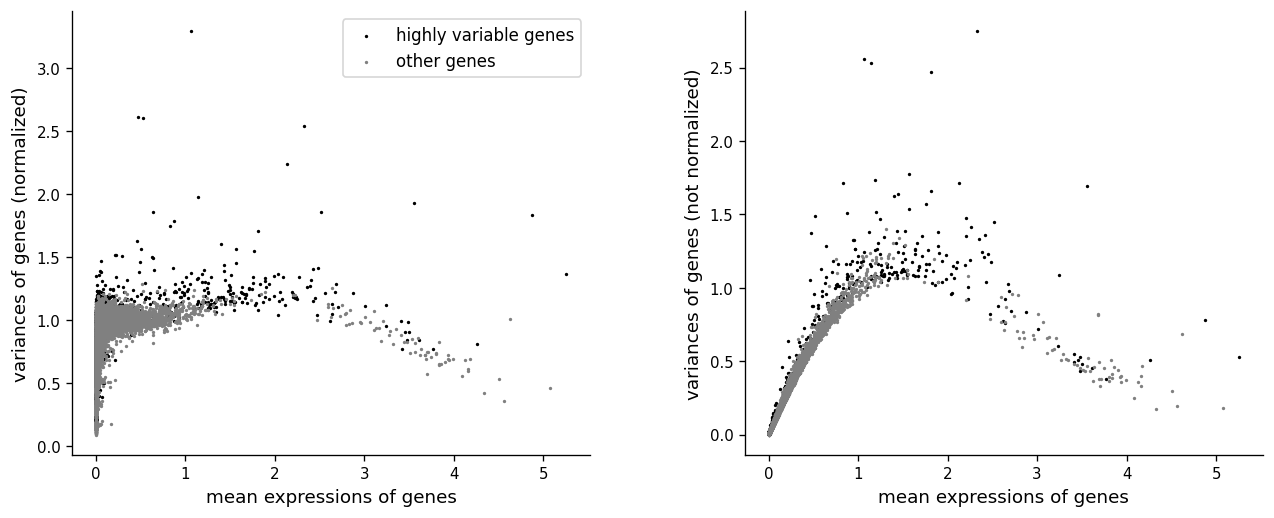

<Figure size 768x576 with 0 Axes>

In [5]:
# Visualize HVG dispersion
sc.pl.highly_variable_genes(adata)
plt.savefig('../figures/02_hvg_plot.png', dpi=150, bbox_inches='tight')

## 2.3 — Scale + PCA

**Scaling:** Each gene is centered (mean=0) and scaled (std=1) so no gene dominates PCA due to high variance.  
**PCA:** Reduces 3,000 HVGs to 50 principal components. Captures ~80% of variance with a fraction of the dimensions.

In [6]:
sc.pp.scale(adata, max_value=10)  # clip at 10 std to handle outliers
adata = run_pca(adata, n_comps=50)

/Users/jess/Documents/Data Projects/Projets Github/.venv-aml-tcga/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


PCA done: 50 components


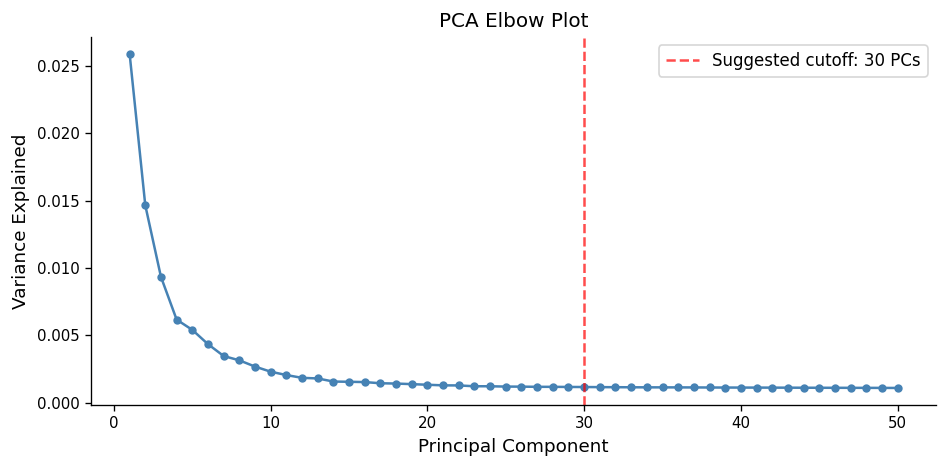

In [7]:
# Elbow plot — how many PCs are informative?
fig, ax = plt.subplots(figsize=(8, 4))
variance_ratio = adata.uns['pca']['variance_ratio']
ax.plot(range(1, len(variance_ratio)+1), variance_ratio, 'o-', color='steelblue', markersize=4)
ax.axvline(x=30, color='red', linestyle='--', alpha=0.7, label='Suggested cutoff: 30 PCs')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained')
ax.set_title('PCA Elbow Plot')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/02_pca_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

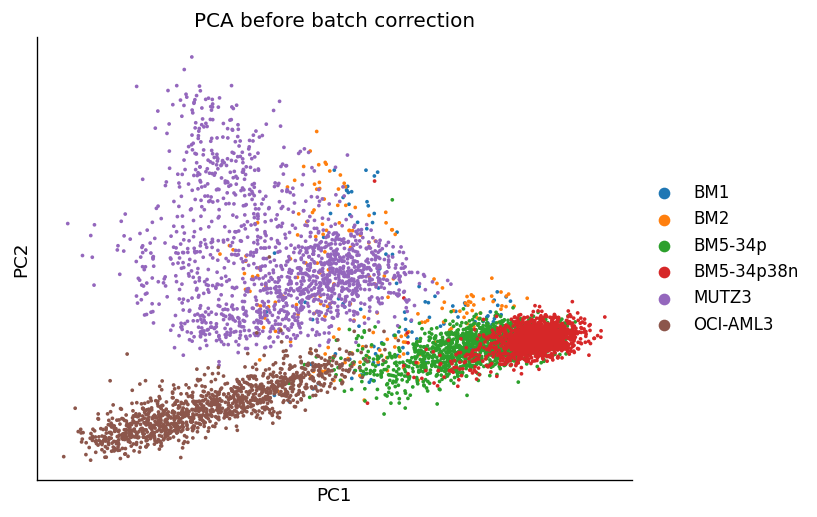

<Figure size 768x576 with 0 Axes>

In [8]:
# PCA colored by sample — shows batch effect BEFORE correction
sc.pl.pca(adata, color='sample', title='PCA before batch correction')
plt.savefig('../figures/02_pca_before_harmony.png', dpi=150, bbox_inches='tight')

## 2.4 — Harmony batch correction

If the PCA above shows cells clustering **by sample** (not by biology), we need batch correction.  
Harmony creates a corrected embedding `X_pca_harmony` that we'll use for UMAP and clustering.

In [9]:
adata = run_harmony_batch_correction(adata, batch_key='sample')

2026-03-12 11:37:25,390 - harmonypy - INFO - Running Harmony (PyTorch on mps)
2026-03-12 11:37:25,391 - harmonypy - INFO -   Parameters:
2026-03-12 11:37:25,391 - harmonypy - INFO -     max_iter_harmony: 10
2026-03-12 11:37:25,392 - harmonypy - INFO -     max_iter_kmeans: 20
2026-03-12 11:37:25,392 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-03-12 11:37:25,393 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-03-12 11:37:25,393 - harmonypy - INFO -     nclust: 100
2026-03-12 11:37:25,394 - harmonypy - INFO -     block_size: 0.05
2026-03-12 11:37:25,395 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1.]
2026-03-12 11:37:25,395 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2.]
2026-03-12 11:37:25,396 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-03-12 11:37:25,396 - harmonypy - INFO -     verbose: True
2026-03-12 11:37:25,397 - harmonypy - INFO -     random_state: 0
2026-03-12 11:37:25,397 - harmonypy - INFO -   Data: 50 PCs × 5996 cells
2026-03-12 11:37:25

Harmony batch correction done on key='sample'


/Users/jess/Documents/Data Projects/Projets Github/.venv-aml-tcga/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


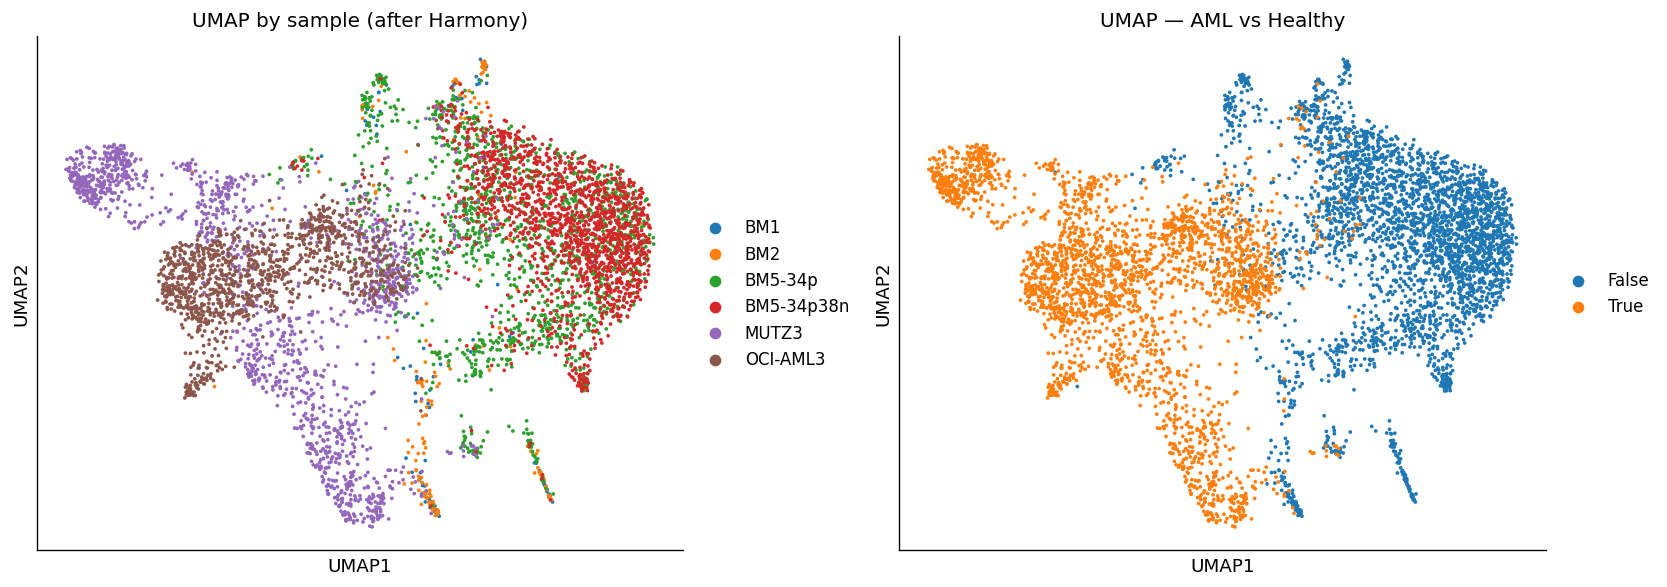

In [10]:
# Quick check: build neighbors on corrected embedding and visualize
sc.pp.neighbors(adata, use_rep='X_pca_harmony', n_neighbors=15)
sc.tl.umap(adata, min_dist=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc.pl.umap(adata, color='sample', title='UMAP by sample (after Harmony)', ax=axes[0], show=False)
sc.pl.umap(adata, color='is_aml', title='UMAP — AML vs Healthy', ax=axes[1], show=False)
plt.tight_layout()
plt.savefig('../figures/02_umap_after_harmony.png', dpi=150, bbox_inches='tight')
plt.show()

# Good result: cells should mix by biology, not separate by sample

In [11]:
# Save for next notebook
adata.write('../data/raw/adata_02_preprocessed.h5ad')
print("Saved: ../data/raw/adata_02_preprocessed.h5ad")

Saved: ../data/raw/adata_02_preprocessed.h5ad


## Summary

| Step | Result |
|------|--------|
| Normalization | 10,000 counts/cell + log1p |
| HVGs | 3,000 genes selected |
| PCA | 50 components |
| Batch correction | Harmony on `sample` key |

**Next:** Notebook 03 — Leiden clustering and cell type annotation.